#### Summary:  
  
This is a notebook to run chromvar on peaks derived from scATAC-seq stored in a Seurat object. This can be reworked to use peaks not entered into a Seurat object. ChromVAR needs 3 inputs. 1) A count matrix that is barcode x peak or sample x peak 2) GRanges identifying peaks and 3) motifs. Motifs can be a custom set, or downloaded from JASPAR. I have code in another location to pull and save JASPAR motifs into a usable format. JASPAR seems to update yearly. The motifs I pulled are all human.  

From here there are follow-up notebooks to compare cell types and disease states.

A reference for ChromVAR can be found here: https://greenleaflab.github.io/chromVAR/articles/Introduction.html

**NOTE:** this notebook illustrates how to make inputs and run ChromVAR with Wang et al. snATAC data, we followed the same commands to do this for the HPAP snATAC data as well.

In [1]:
suppressMessages(library(chromVAR))
suppressMessages(library(motifmatchr))
suppressMessages(library(SummarizedExperiment))

library(Signac)
library(Seurat)
library(JASPAR2020)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(readr)
library(stringr)
library(dplyr)
set.seed(1234)
library(ggplot2)

library(Matrix)
library(BiocParallel)
register(MulticoreParam(8))

#### Send to channel code
library(parallel)
library(qvalue)

Attaching SeuratObject

Attaching sp


Attaching package: ‘Seurat’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays


Loading required package: BSgenome

Loading required package: Biostrings

Loading required package: XVector


Attaching package: ‘Biostrings’


The following object is masked from ‘package:base’:

    strsplit


Loading required package: rtracklayer


Attaching package: ‘dplyr’


The following objects are masked from ‘package:Biostrings’:

    collapse, intersect, setdiff, setequal, union


The following object is masked from ‘package:XVector’:

    slice


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are maske

In [2]:
outdir <- '/dir/with/phenotype/assoc/outputs/ATAC/ChromVAR'

# 1. Create long format matrices for Wang et al. snATAC data
Did this with scripts, see notion note

# 2. Read in LFMs and make merged barcode x union peak matrix

In [4]:
motif.ix <- readRDS('/path/to/240322_WE_MotifMatches_Union_Peaks.RDS')
dim(motif.ix)
head(rownames(motif.ix))

[1] 291821    692

[1] "chr1-1000073-1000373"     "chr1-100036794-100037094"
[3] "chr1-100037929-100038229" "chr1-100046138-100046438"
[5] "chr1-100046907-100047207" "chr1-100050188-100050403"

## Wang snATAC

In [7]:
lfm_dir <- file.path(outdir,'long_format_matrices/')
list.files(lfm_dir)

[1] "JYH_792" "MM_110"  "MM_123"  "MM_124"  "MM_56"   "MM_59"   "MM_80"  
 [8] "MM_86"   "MM_89"   "MM_95"   "MM_98"

In [8]:
#read in all LFMs and add any missing information
lfms <- list()
hvws <- rownames(motif.ix)
samples <- list.files(lfm_dir)

print(Sys.time())
for (samp in samples) {
    print(paste0(which(samples %in% samp) * 100 /length(samples),"% - ", samp))

    #Read in the atac lfm matrix and make sure is union peaks, also add sample prefix to barcodes
    lfm_in <- read.table(paste0(lfm_dir, samp,'/',samp,'.long_fmt_mtx.txt.gz'), col.names=c('Window','Barcode','Count'))
    lfm_in$Window <- as.factor(lfm_in$Window)
    lfm_in$Barcode <- paste(samp,lfm_in$Barcode,sep='_')
    lfm_in$Barcode <- as.factor(lfm_in$Barcode)    
    lfm_in_filt <- filter(lfm_in, Window %in% hvws)
    print(dim(lfm_in_filt))

    mis_windows <- hvws[!hvws %in% levels(lfm_in_filt$Window)]
    print(length(mis_windows))

    #make sure there are missing_windows
    if (length(mis_windows) > 0){
        print('Adding missing windows')
        #create a new long format matrix (sm) with the missing windows added as 0 counts
        filler_bc <- as.character(lfm_in_filt$Barcode[[1]])
        print(paste("Using filler BC:",filler_bc,sep=" "))
        new_rows <- cbind(as.data.frame(mis_windows),
                          as.data.frame(rep(filler_bc),length(mis_windows)),
                          as.data.frame(rep(0,length(mis_windows))))
        colnames(new_rows) <- c("Window","Barcode","Count")
        lfm_in_fix <- rbind(lfm_in_filt,new_rows)
    #if there aren't, set lfm to df
    } else {
        print('No windows were missing')
        lfm_in_fix <- lfm_in_filt
    }
    print(dim(lfm_in_fix))
    
    #finalize matrix
    lfm_in_fix$Window <- factor(lfm_in_fix$Window, levels=hvws)
    lfm_in_sort <- lfm_in_fix[order(lfm_in_fix$Window),]
    lfm_in_sort$Barcode <- as.factor(lfm_in_sort$Barcode)
    lfms[[samp]] <- with(lfm_in_sort, sparseMatrix(i=as.numeric(Window), j=as.numeric(Barcode), x=Count, dimnames=list(levels(Window), levels(Barcode))))
    print(dim(lfms[[samp]]))
    gc()
    print('')
}

gc()
summary(lfms)
print(Sys.time())

[1] "2025-01-16 11:21:44 PST"
[1] "9.09090909090909% - JYH_792"
[1] 20204730        3
[1] 919
[1] "Adding missing windows"
[1] "Using filler BC: JYH_792_AAACTCGAGTATACCC-1"


Warning message in as.data.frame.vector(x, ..., nm = nm):
“'row.names' is not a character vector of length 1 -- omitting it. Will be an error!”


[1] 20205649        3
[1] 291821   5202
[1] ""
[1] "18.1818181818182% - MM_110"
[1] 16932328        3
[1] 2678
[1] "Adding missing windows"
[1] "Using filler BC: MM_110_AAACTGCGTGATGCGA-1"


Warning message in as.data.frame.vector(x, ..., nm = nm):
“'row.names' is not a character vector of length 1 -- omitting it. Will be an error!”


[1] 16935006        3
[1] 291821   5759
[1] ""
[1] "27.2727272727273% - MM_123"
[1] 36139541        3
[1] 187
[1] "Adding missing windows"
[1] "Using filler BC: MM_123_AAACGAACATGACTGT-1"


...

[1] 23642096        3
[1] 291821   6009
[1] ""


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,11937406,637.6,17189071,918,14813764,791.2
Vcells,652853876,4980.9,1151454884,8785,1151454884,8785.0


Warning message in format(as.integer(ll)):
“NAs introduced by coercion to integer range”


        Length     Class     Mode
JYH_792 1518052842 dgCMatrix S4  
MM_110  1680597139 dgCMatrix S4  
MM_123          NA dgCMatrix S4  
MM_124          NA dgCMatrix S4  
MM_56   1582545283 dgCMatrix S4  
MM_59   1449766728 dgCMatrix S4  
MM_80   2081267372 dgCMatrix S4  
MM_86   1732833098 dgCMatrix S4  
MM_89   1820963040 dgCMatrix S4  
MM_95   1502586329 dgCMatrix S4  
MM_98   1753552389 dgCMatrix S4  

[1] "2025-01-16 11:41:16 PST"


In [9]:
#make final lfm
lfm <- do.call(cbind, lfms)
dim(lfm)
head(lfm)

[1] 291821  72109

   [[ suppressing 34 column names ‘JYH_792_AAACGAAAGCATTGGG-1’, ‘JYH_792_AAACGAAAGGGTCTGA-1’, ‘JYH_792_AAACGAAAGTAGACCG-1’ ... ]]



6 x 72109 sparse Matrix of class "dgCMatrix"
                                                                              
chr1-1000073-1000373     . . . . . . . . . . . . . 2 . 1 . . . . . . . . . . .
chr1-100036794-100037094 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-100037929-100038229 2 . . . 2 . . . 2 . . 2 . . 2 . . . . . 2 . . 3 . . .
chr1-100046138-100046438 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-100046907-100047207 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-100050188-100050403 . . . . . . . . . . . . . . . . . . . . . . . . . . .
                                             
chr1-1000073-1000373     . . . . . . . ......
chr1-100036794-100037094 . . . . . . . ......
chr1-100037929-100038229 . . . . . . 1 ......
chr1-100046138-100046438 . . . . . . . ......
chr1-100046907-100047207 . . . . . . . ......
chr1-100050188-100050403 . . . . . . . ......

 .....suppressing 72075 columns in show(); maybe adjust 'options(max.print= *, 

In [10]:
#how many peaks have counts -- almost all
length(names(which(rowSums(lfm) != 0)))
names(which(rowSums(lfm) == 0))

[1] 291821

character(0)

# 3. Make inputs and run ChromVAR

In [11]:
#Prep inputs for SummarizedExperiment
sc.data <- lfm

# Extract peak locations and reformat into GRanges object
bed = str_split_fixed(rownames(sc.data), "\\-", 3) #This may need to be modified depending on your peak naming convention
gr= GRanges(seqnames = bed[,1], ranges = IRanges(start = as.numeric(bed[,2]), end = as.numeric(bed[,3])))

In [12]:
# annotation <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
# seqlevelsStyle(annotation) <- 'UCSC'

In [13]:
#Use the matrix and GRanges to make a SummarizedExperiment to put into chromvar and add metadata
fragment.counts <- SummarizedExperiment(assays=list(counts=sc.data), rowRanges=gr)
# fragment.counts.stored <- fragment.counts
fragment.counts <- addGCBias(fragment.counts, genome=BSgenome.Hsapiens.UCSC.hg38)
fragment.counts

class: RangedSummarizedExperiment 
dim: 291821 72109 
metadata(0):
assays(1): counts
rownames(291821): chr1-1000073-1000373 chr1-100036794-100037094 ...
  chrY-9652738-9653038 chrY-9812080-9812380
rowData names(1): bias
colnames(72109): JYH_792_AAACGAAAGCATTGGG-1 JYH_792_AAACGAAAGGGTCTGA-1
  ... MM_98_TTTGTGTGTGAGAGTC-1 MM_98_TTTGTGTTCTCTTAAC-1
colData names(0):

In [14]:
#remove peaks or motifs with no counts
fragment.counts.sub <- fragment.counts[names(which(rowSums(lfm) != 0)),]
fragment.counts.sub

motif.ix.sub <- motif.ix[names(which(rowSums(lfm) != 0)),]
motif.ix.sub

class: RangedSummarizedExperiment 
dim: 291821 72109 
metadata(0):
assays(1): counts
rownames(291821): chr1-1000073-1000373 chr1-100036794-100037094 ...
  chrY-9652738-9653038 chrY-9812080-9812380
rowData names(1): bias
colnames(72109): JYH_792_AAACGAAAGCATTGGG-1 JYH_792_AAACGAAAGGGTCTGA-1
  ... MM_98_TTTGTGTGTGAGAGTC-1 MM_98_TTTGTGTTCTCTTAAC-1
colData names(0):

class: RangedSummarizedExperiment 
dim: 291821 692 
metadata(0):
assays(1): motifMatches
rownames(291821): chr1-1000073-1000373 chr1-100036794-100037094 ...
  chrY-9652738-9653038 chrY-9812080-9812380
rowData names(1): bias
colnames(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1
  MA0597.2_THAP1
colData names(1): name

In [15]:
# Run chromVAR -- approx 30 mins
print(Sys.time())
dev <- computeDeviations(object=fragment.counts.sub, annotations=motif.ix.sub)#, expectation=expected)#
head(dev)
print(Sys.time())

[1] "2025-01-16 11:45:09 PST"


class: chromVARDeviations 
dim: 6 72109 
metadata(0):
assays(2): deviations z
rownames(6): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA0066.1_PPARG
  MA0069.1_PAX6
rowData names(3): name fractionMatches fractionBackgroundOverlap
colnames(72109): JYH_792_AAACGAAAGCATTGGG-1 JYH_792_AAACGAAAGGGTCTGA-1
  ... MM_98_TTTGTGTGTGAGAGTC-1 MM_98_TTTGTGTTCTCTTAAC-1
colData names(0):

[1] "2025-01-16 12:50:03 PST"


In [16]:
saveRDS(dev, file.path(outdir,'outputs',"250116_HM_ChromVAR_Object_Union_Peaks_Wang.RDS"))

# 4. Collect details for downstream analysis

In [17]:
# Load in motifs object
jaspar.motifs <- readRDS(file ='/dir/with/motif/object/jaspar_2022_object.Rdata')

In [18]:
dev
jaspar.motifs

class: chromVARDeviations 
dim: 692 72109 
metadata(0):
assays(2): deviations z
rownames(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1
  MA0597.2_THAP1
rowData names(3): name fractionMatches fractionBackgroundOverlap
colnames(72109): JYH_792_AAACGAAAGCATTGGG-1 JYH_792_AAACGAAAGGGTCTGA-1
  ... MM_98_TTTGTGTGTGAGAGTC-1 MM_98_TTTGTGTTCTCTTAAC-1
colData names(0):

PFMatrixList of length 692
names(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1 MA0597.2_THAP1

In [19]:
#This is a cell by motif deviation score (aka accessibility) matrix
devtab = deviationScores(dev)
head(devtab)

,JYH_792_AAACGAAAGCATTGGG-1,JYH_792_AAACGAAAGGGTCTGA-1,JYH_792_AAACGAAAGTAGACCG-1,JYH_792_AAACGAACAAATAGTG-1,JYH_792_AAACGAACATGCTATG-1,JYH_792_AAACGAAGTACAAATG-1,JYH_792_AAACGAAGTTCCCAAA-1,JYH_792_AAACGAAGTTCTGAAC-1,JYH_792_AAACGAAGTTGTGAGG-1,JYH_792_AAACGAATCGCGCCAA-1,⋯,MM_98_TTTGGTTCAGTAACTC-1,MM_98_TTTGGTTGTCAACTAC-1,MM_98_TTTGGTTGTTTGCCCT-1,MM_98_TTTGGTTTCTATCTAC-1,MM_98_TTTGGTTTCTCGCGTT-1,MM_98_TTTGGTTTCTCTGCGT-1,MM_98_TTTGTGTAGCTGAAAT-1,MM_98_TTTGTGTAGTGCCCTG-1,MM_98_TTTGTGTGTGAGAGTC-1,MM_98_TTTGTGTTCTCTTAAC-1
MA0030.1_FOXF2,-0.1919693,-1.1262077,0.7225387,0.1773992,0.33374156,1.2936411,-1.1292179,0.1405144,0.004983018,0.46126009,⋯,0.09496833,0.9374360,1.1342824,0.065413021,1.1139035,0.6562983,-0.64983273,0.7903952,-0.1147513,2.2395908
MA0031.1_FOXD1,-1.3840475,-1.0376873,1.7254363,-0.3353514,1.68259636,0.8322373,-1.3709051,0.5649841,2.115988986,-0.08217287,⋯,1.30727331,0.6777154,3.3324235,-0.643384871,1.2100381,0.7261078,-1.00977876,1.9437717,1.9535596,1.1474877
MA0051.1_IRF2,-0.3513077,0.9960281,2.4494963,-1.8214415,2.44537063,-1.9537110,0.4269174,-1.9571387,0.147142314,0.30061748,⋯,-0.12503214,1.8028890,-0.1806708,-0.274212102,0.5020460,2.3638528,0.30540133,-0.1063866,-1.7440622,1.5820870
MA0059.1_MAX::MYC,1.7498621,0.8176823,1.2804541,-0.3258601,0.90380796,-1.0681871,0.4244321,-0.7585446,1.544728754,0.84190555,⋯,0.92901519,-0.3659852,0.7420400,-0.204274940,-1.1740254,-0.9946830,0.03500785,-0.5265109,-1.0563219,0.6603728
MA0066.1_PPARG,0.9392748,0.9944584,-1.6966272,-0.6635538,0.08534548,0.1374922,-1.4814704,0.4091975,0.837238067,0.66204685,⋯,-0.34404151,-1.2640450,-0.2397345,0.009763407,-1.4712446,0.8956258,-0.59069177,-1.2953325,-0.2280706,1.4547094
MA0069.1_PAX6,-1.2216093,1.0101924,-0.5554457,0.4456593,-0.71289482,0.5616701,-0.5374692,-0.6012099,1.584321585,0.94207371,⋯,1.14654545,0.9312225,-1.6337136,0.787711079,-0.9130177,2.4162118,1.38700376,-1.5402880,4.0801953,2.0048079


In [20]:
# Variation of accessibiility across deviation scores, basically the standard errror. Null is about 1
variability <- computeVariability(dev)
head(variability)

,name,variability,bootstrap_lower_bound,bootstrap_upper_bound,p_value,p_value_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,FOXF2,1.114410,1.108255,1.120430,0.000000e+00,0.000000e+00
MA0031.1_FOXD1,FOXD1,1.186893,1.180350,1.192626,0.000000e+00,0.000000e+00
MA0051.1_IRF2,IRF2,1.163828,1.156624,1.170720,0.000000e+00,0.000000e+00
MA0059.1_MAX::MYC,MAX::MYC,1.057427,1.051871,1.063531,7.405833e-104,1.259174e-103
MA0066.1_PPARG,PPARG,1.054163,1.048691,1.059577,9.997309e-93,1.659026e-92
MA0069.1_PAX6,PAX6,1.085623,1.080196,1.091577,4.384212e-226,9.631349e-226


In [ ]:
motifdata = cbind(sapply(jaspar.motifs, function(x) unlist(x@name)),sapply(jaspar.motifs, function(x) unlist(x@matrixClass )))                                                  
motifdata             #  sapply(pfm, function(x) x@tags$symbol )  ,     sapply(pfm, function(x) x@tags$family ))

In [ ]:
#Save devscores, motifdata, and info
write.table(devtab, file=file.path(outdir,'outputs','devscores_Union_Peaks_Wang.txt'),quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(motifdata, file=file.path(outdir,'outputs','motifdata_Union_Peaks_Wang.txt'),quote = FALSE, col.names = FALSE,sep='\t')
write.table(variability, file=file.path(outdir,'outputs','variability_Union_Peaks_Wang.txt'),quote = FALSE, col.names = TRUE, row.names = TRUE, sep='\t')

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


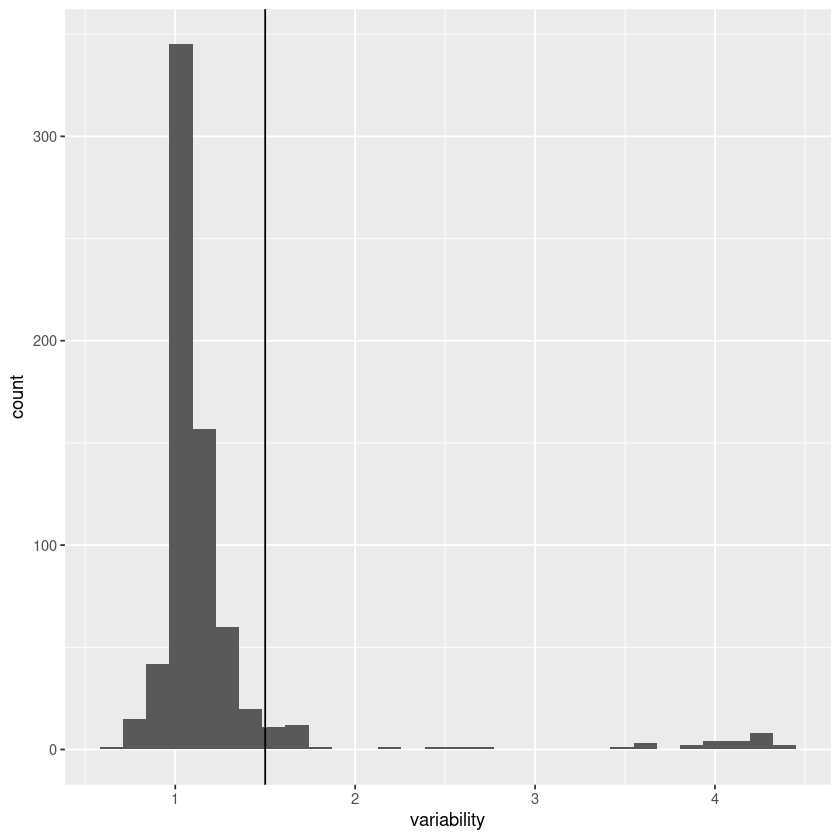

In [24]:
# Variability distirbution
ggplot(variability, aes(x=variability)) +
geom_histogram() + geom_vline(xintercept = 1.5)